<a href="https://colab.research.google.com/github/sreuter1/transfer_learning/blob/main/ViT_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Importing Needed Libraries - Routing to Proper Device

In [12]:
import os
import random
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from torchvision import datasets
from torchvision.transforms import v2
from torch.utils.data import DataLoader, random_split, Dataset
import torch.nn.functional as F
from PIL import Image

print("torch:", torch.__version__)
device = "cuda"  # Change device in the runtime settings - to GPU T4
print(torch.cuda.is_available())
print("device:", device)

def set_seed(seed: int = 42):                                                                       # Here for reproducability
    """Make results as reproducible as possible across runs."""
    # os.environ["PYTHONHASHSEED"] = str(seed)
    os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"

    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    # Deterministic flags (safe on CPU; on GPU some ops may error if non-deterministic)
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True
    torch.backends.cuda.matmul.allow_tf32 = False
    torch.backends.cudnn.allow_tf32 = False
    try:
        torch.use_deterministic_algorithms(True)
    except Exception as e:
        print("Warning: could not enable full deterministic algorithms:", e)

set_seed(42)                                                                                        # Here for reproducability


torch: 2.11.0+cu128
True
device: cuda


Importing From Kaggle API - Get Kaggle key first - Already Downloaded

In [13]:
!export KAGGLE_API_TOKEN=KGAT_6e0db17c19cd9ec6f55621b971c1014d

!mkdir -p ~/.kaggle && echo KGAT_6e0db17c19cd9ec6f55621b971c1014d > ~/.kaggle/access_token && chmod 666 ~/.kaggle/access_token

!kaggle competitions list

!export KAGGLE_API_TOKEN=KGAT_d77bc5e53c781f271763950cf13abd1c

!mkdir -p ~/.kaggle && echo KGAT_d77bc5e53c781f271763950cf13abd1c > ~/.kaggle/access_token && chmod 600 ~/.kaggle/access_token

!kaggle competitions list

ref                                                                              deadline             category         reward  teamCount  userHasEntered  
-------------------------------------------------------------------------------  -------------------  --------  -------------  ---------  --------------  
https://www.kaggle.com/competitions/passenger-screening-algorithm-challenge      2017-12-15 23:59:00  Featured  1,500,000 Usd        518           False  
https://www.kaggle.com/competitions/zillow-prize-1                               2018-01-10 15:59:00  Featured  1,200,000 Usd       3770           False  
https://www.kaggle.com/competitions/data-science-bowl-2017                       2017-04-12 23:59:00  Featured  1,000,000 Usd       1972           False  
https://www.kaggle.com/competitions/vesuvius-challenge-ink-detection             2023-06-14 23:59:00  Featured  1,000,000 Usd       1249           False  
https://www.kaggle.com/competitions/arc-prize-2026-arc-agi-3          

In [14]:
# Code that kaggle said to run to get access to the competition files
import kagglehub

# Download latest version
path = kagglehub.competition_download('ucsc-cse-144-spring-2026-final-project')

print("Path to competition files:", path)

Path to competition files: /root/.cache/kagglehub/competitions/ucsc-cse-144-spring-2026-final-project


Data Pipeline - Dataset and DataLoader - IN PROGRESS

In [15]:

batch_size = 32  # For now, can change to 64?
num_workers = 0                                                                 # Here for reproducability
mean=[0.485, 0.456, 0.406]                                                      # ImageNet stats - that is what the model was trained on
std=[0.229, 0.224, 0.225]
val_p = 0.2 # portion of training data


class UnlabeledDataset(Dataset):
  def __init__(self, root, transform=None):
      self.root   = root
      self.transform = transform
      self.images    = sorted(os.listdir(root))

  def __len__(self):
      return len(self.images)

  def __getitem__(self, idx):
      img_path = os.path.join(self.root, self.images[idx])
      image    = Image.open(img_path).convert('RGB')
      if self.transform:
          image = self.transform(image)
      return image, self.images[idx]

train_path = path + '/train'
test_path = path + '/test'


#data augmentation to expand training dataset
train_tf = v2.Compose([
           v2.ToImage(),
           v2.ToDtype(torch.uint8, scale=True),
           v2.Resize((224, 224)),
           v2.RandomResizedCrop(224, scale=(0.6, 1.0)),
           v2.RandomHorizontalFlip(),                          # Augmentation
           v2.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),   #Augmentation
           v2.ToDtype(torch.float32, scale=True),
           v2.Normalize(mean, std)
])

test_tf = v2.Compose([
          v2.ToImage(),
          v2.Resize((224, 224)),
          v2.Normalize(mean, std)
])

train_set = datasets.ImageFolder(root=train_path, transform=train_tf)
val_set   = datasets.ImageFolder(root=train_path,  transform=test_tf)
test_set   = UnlabeledDataset(root=test_path,  transform=test_tf)

train_size = int((1-val_p) * len(train_set))
val_size   = len(train_set) - train_size

train_set, val_set = random_split(train_set, [train_size, val_size])

train_loader = DataLoader(dataset=train_set,
                          batch_size=batch_size,
                          shuffle=True,
                          num_workers=0
)
val_loader =   DataLoader(dataset=val_set,
                          batch_size=batch_size,
                          shuffle=False,
                          num_workers=0
)
test_loader =  DataLoader(dataset=test_set,
                          batch_size=batch_size,
                          shuffle=False,
                          num_workers=0
)

print("train/val/test:", len(train_set), len(val_set), len(test_set))

train/val/test: 863 216 1036


Defining the ViT model

In [16]:
import torchvision.models as models

#replace classifier head
number_classes = 100
#attempting to implement low-rank adaptation to help with overfitting issue
class LoRALinear(nn.Module):
  #rank and alpha -> hyperparameters for controlling how the model learns
  #rank controls information bottleneck

  #widening LoRA rank from 4->16 since the dataset is relatively small
  def __init__(self, linear:nn.Linear, rank=16, alpha=1):
    super().__init__()
    self.frozen_linear = linear #keep original layer
    self.rank = rank
    self.scale = alpha/rank

    in_f = linear.in_features
    out_f = linear.out_features

    self.lora_A = nn.Parameter(torch.empty(rank, in_f))
    self.lora_B = nn.Parameter(torch.zeros(out_f, rank))

    nn.init.kaiming_uniform_(self.lora_A, a=5**0.5)
    for p in self.frozen_linear.parameters():
      p.requires_grad=False

  @property                             #python decorator to access a method as if it were an attribute
  def weight(self):
    return self.frozen_linear.weight

  @property
  def bias(self):
    return self.frozen_linear.bias

  @property
  def in_features(self):
    return self.frozen_linear.in_features

  @property
  def out_features(self):
    return self.frozen_linear.out_features

  def forward(self, x:torch.Tensor) -> torch.Tensor:
    frozen_out = self.frozen_linear(x)
    lora_out = (x @ self.lora_A.T) @ self.lora_B.T
    return frozen_out + lora_out * self.scale

def add_lora(model: nn.Module, rank=4, alpha=4.0):
  injected = 0
  for name, module in model.named_modules():
    if isinstance(module, nn.MultiheadAttention):
      module.out_proj = LoRALinear(module.out_proj, rank=rank, alpha=alpha)
      injected += 1
  print(f"Injected LoRA into {injected} attention layers")
  return model


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
number_classes = 100

model = models.vit_b_16(weights=models.ViT_B_16_Weights.IMAGENET1K_V1)

for param in model.parameters():
  param.requires_grad = False
model = add_lora(model, rank=4, alpha=4)
model.heads.head = nn.Sequential(
    nn.Dropout(p=0.3),
    nn.Linear(model.heads.head.in_features, number_classes))
model = model.to(device)


trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())
print(f"Trainable: {trainable:,} / Total: {total:,}")



Injected LoRA into 12 attention layers
Trainable: 150,628 / Total: 85,949,284


Training Function

In [17]:
# Q3.1: Training function
criterion = nn.CrossEntropyLoss()
#optimizer = torch.optim.Adagrad(model.parameters(), lr=0.01) --> not going to use Adagrad; uncommon for ViT fine-tuning and can hurt convergence
optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-3,
    weight_decay=0.01
)

scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=1e-3,
    steps_per_epoch=len(train_loader),
    epochs=30,
    pct_start=0.1         #lowered from 20% --> 10%
)

def mixup_batch(x, y, num_classes=100, alpha=0.4):
    lam = torch.distributions.Beta(alpha, alpha).sample().item()
    idx = torch.randperm(x.size(0), device=x.device)

    mixed_x = lam * x + (1 - lam) * x[idx]

    # integers go in, soft float labels come out
    y_a = F.one_hot(y, num_classes).float()
    y_b = F.one_hot(y[idx], num_classes).float()
    mixed_y = lam * y_a + (1 - lam) * y_b      # e.g. [0.7, 0, 0.3, 0, ...]

    return mixed_x, mixed_y, y

def train_one_epoch(model, loader):
    """Train for one epoch and return (avg_loss, accuracy)."""
    # - Set model to training mode
    model.train()
    total_loss = 0.0
    correct = 0
    total = 0

    # - Loop through batches in the loader
    for batch, (X,y) in enumerate(loader):
        X, y = X.to(device), y.to(device)
        X, y_soft, y_hard = mixup_batch(X, y)
        optimizer.zero_grad()           #   * Zero gradients
        prediction = model(X)           #   * Forward pass
        loss = criterion(prediction,y_soft)  #   * Compute loss
        loss.backward()                 #   * Backward pass
        optimizer.step()                #   * Optimizer step
        scheduler.step()

        total_loss += loss.item()
        predicted = prediction.argmax(dim=1)
        correct+= (predicted == y_hard).sum().item()
        total += y.size(0)
    avg_loss = total_loss/len(loader)
    accuracy = correct/total

    # - Track total loss and accuracy (IMPORTANT: get predicted labels and compare with targets)
    # - Return average loss and accuracy
    return avg_loss, accuracy
    # ========== YOUR CODE ENDS HERE ============

Validation Function

In [18]:
# Q3.2: Validation function
@torch.no_grad()
def evaluate(model, loader):
    """Evaluate model and return (avg_loss, accuracy)."""

    print(model.training)
    model.eval()                                 # - Set model to evaluation mode
    print(model.training)

    total_loss = 0.0                             # - Creating variables for loss and accuracy calculations
    correct = 0
    total = 0

    with torch.no_grad():
      for X, y in loader:
          X, y = X.to(device), y.to(device)        # - Loop through batches without computing gradients
          prediction = model(X)
          loss = criterion(prediction,y)
          total_loss += loss.item()
          predicted = prediction.argmax(dim=1)
          correct+= (predicted == y).sum().item()
          total += y.size(0)
      avg_loss = total_loss/len(loader)            # computing loss and accuracy
      accuracy = correct/total

    return avg_loss, accuracy

Training Loop

In [19]:
# Q3.3: Training loop with checkpointing
epochs = 30             #changed from 10 -> 30
history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
best_val_acc = 0.0
best_epoch = -1
ckpt_path = "./checkpoints/best_transfer.ViT.pt"
os.makedirs(os.path.dirname(ckpt_path), exist_ok=True)

# - Loop through epochs
for i in range(epochs):
    # - Each epoch: train, validate, log metrics
    train_loss, train_accuracy = train_one_epoch(model, train_loader)
    valid_loss, valid_accuracy = evaluate(model, val_loader)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_accuracy)
    history["val_loss"].append(valid_loss)
    history["val_acc"].append(valid_accuracy)

    # - Track best validation accuracy and save checkpoint when improved
    if (valid_accuracy > best_val_acc):
        best_epoch = i
        best_val_acc = valid_accuracy
        torch.save(
            {"model_state_dict": model.state_dict(), "epoch": i},
            ckpt_path
        )

    # - Print training and validation metrics each epoch
    print("train_loss:", train_loss, "train_accuracy:", train_accuracy)
    print("valid_loss:", valid_loss, "valid_accuracy:", valid_accuracy)

# ========== YOUR CODE ENDS HERE ============

print("Best val acc:", best_val_acc, "at epoch", best_epoch)
print("Saved to:", ckpt_path)

True
False
train_loss: 4.7018260602597834 train_accuracy: 0.016222479721900347
valid_loss: 4.506764003208706 valid_accuracy: 0.004629629629629629
True
False
train_loss: 4.274423113575688 train_accuracy: 0.046349942062572425
valid_loss: 3.752304792404175 valid_accuracy: 0.18981481481481483
True
False
train_loss: 3.5873637905827276 train_accuracy: 0.09501738122827347
valid_loss: 3.003446340560913 valid_accuracy: 0.24537037037037038
True
False
train_loss: 2.939521038973773 train_accuracy: 0.24333719582850522
valid_loss: 2.616659198488508 valid_accuracy: 0.30092592592592593
True
False
train_loss: 2.433694186034026 train_accuracy: 0.3290845886442642
valid_loss: 2.320357254573277 valid_accuracy: 0.375
True
False
train_loss: 2.164772121994584 train_accuracy: 0.36964078794901506
valid_loss: 2.0908624274390086 valid_accuracy: 0.42592592592592593
True
False
train_loss: 1.9610063544026128 train_accuracy: 0.4101969872537659
valid_loss: 2.006042923246111 valid_accuracy: 0.44907407407407407
True
Fal

Curves

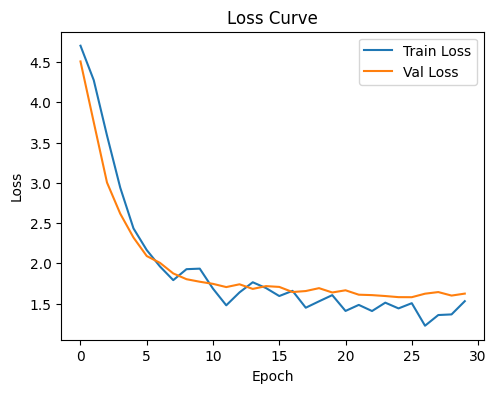

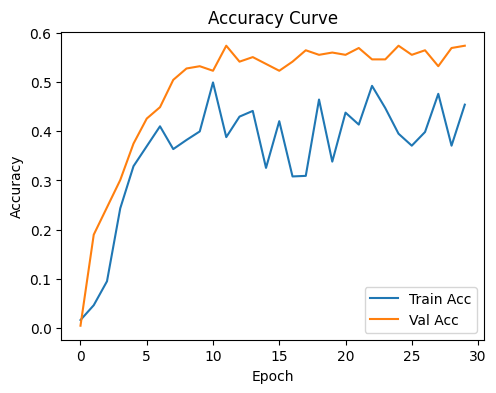

In [20]:
# Q3.4: Plot curves
# ========== YOUR CODE STARTS HERE ==========
# TODO:
# - Create two plots: one for loss (train vs val), one for accuracy (train vs val)
# - Use the history dictionary to get the values
# - Add labels, legends, and display the plots

# Loss ------------------------------------------------------------------------

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'],   label='Val Loss')
plt.title('Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Accuracy --------------------------------------------------------------------

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history['train_acc'], label='Train Acc')
plt.plot(history['val_acc'],   label='Val Acc')
plt.title('Accuracy Curve')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# ========== YOUR CODE ENDS HERE ============

Testing

In [21]:
# Q4: Test evaluation
# ========== YOUR CODE STARTS HERE ==========
# TODO:
# - Load the best checkpoint (it's a dictionary with 'model_state_dict' and 'epoch')
# - Load the model state from the checkpoint
# - Evaluate on the test set
# - Print test loss and accuracy

checkpoint = torch.load(ckpt_path)
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

# Evaluate the best model state from the checkpoint
test_loss, test_acc = evaluate(model, val_loader)
# ========== YOUR CODE ENDS HERE ============

print(f"Test loss: {test_loss:.4f} | Test acc: {test_acc:.4f}")

False
False
Test loss: 1.7614 | Test acc: 0.5463
